## Import + config

In [1]:
from pathlib import Path
import json, re, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx   
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

DATA_DIR = Path(r"E:\AIO\Project\repo-aiops-minhtq\w2\lab-w2-evidence-driven-remediation-20260611\data-pack")
EVAL_DIR = DATA_DIR / "eval"

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True

## Load incident

In [2]:
def load_incident(eid="E01"):
    path = EVAL_DIR / f"{eid}.json"
    with open(path, "r", encoding="utf-8") as f:
        inc = json.load(f)
    return inc

incident = load_incident("E01")
incident.keys()

dict_keys(['incident_id', 'detected_at', 'trigger_alert', 'topology', 'metrics_window', 'traces', 'logs'])

## Xem tổng quan incident

In [3]:
def incident_summary(inc):
    metric_series = inc["metrics_window"]["samples"]
    return {
        "incident_id": inc["incident_id"],
        "detected_at": inc["detected_at"],
        "trigger_service": inc["trigger_alert"]["service"],
        "trigger_rule": inc["trigger_alert"]["rule_id"],
        "severity": inc["trigger_alert"]["severity"],
        "num_metric_series": len(metric_series),
        "metric_names": list(metric_series.keys()),
        "num_logs": len(inc["logs"]),
        "num_traces": len(inc["traces"]),
    }

incident_summary(incident)

{'incident_id': 'E01-2026-06-10-001',
 'detected_at': '2026-06-10T14:23:00Z',
 'trigger_service': 'checkout-svc',
 'trigger_rule': 'latency-p99-high',
 'severity': 'critical',
 'num_metric_series': 3,
 'metric_names': ['payment-svc.cpu',
  'payment-svc.latency_p99_ms',
  'checkout-svc.latency_p99_ms'],
 'num_logs': 500,
 'num_traces': 480}

## Convert metrics sang dataframe

In [4]:
def metrics_to_df(inc):
    rows = []
    detected_at = pd.to_datetime(inc["detected_at"], utc=True)

    for series_key, samples in inc["metrics_window"]["samples"].items():
        service, metric = series_key.split(".", 1)

        for ts, value in samples:
            ts = pd.to_datetime(ts, utc=True)
            rows.append({
                "incident_id": inc["incident_id"],
                "detected_at": detected_at,
                "ts": ts,
                "service": service,
                "metric": metric,
                "series_key": series_key,
                "value": float(value),
                "phase": "baseline" if ts < detected_at else "incident",
            })

    return pd.DataFrame(rows).sort_values(["series_key", "ts"])

metrics_df = metrics_to_df(incident)
metrics_df.head()

,incident_id,detected_at,ts,service,metric,series_key,value,phase
200,E01-2026-06-10-001,2026-06-10 14:23:00+00:00,2026-06-10 14:08:00+00:00,checkout-svc,latency_p99_ms,checkout-svc.latency_p99_ms,180.613,baseline
201,E01-2026-06-10-001,2026-06-10 14:23:00+00:00,2026-06-10 14:08:45+00:00,checkout-svc,latency_p99_ms,checkout-svc.latency_p99_ms,172.979,baseline
202,E01-2026-06-10-001,2026-06-10 14:23:00+00:00,2026-06-10 14:09:30+00:00,checkout-svc,latency_p99_ms,checkout-svc.latency_p99_ms,176.211,baseline
203,E01-2026-06-10-001,2026-06-10 14:23:00+00:00,2026-06-10 14:10:15+00:00,checkout-svc,latency_p99_ms,checkout-svc.latency_p99_ms,186.816,baseline
204,E01-2026-06-10-001,2026-06-10 14:23:00+00:00,2026-06-10 14:11:00+00:00,checkout-svc,latency_p99_ms,checkout-svc.latency_p99_ms,182.975,baseline


## Plot metrics với đường detected_at

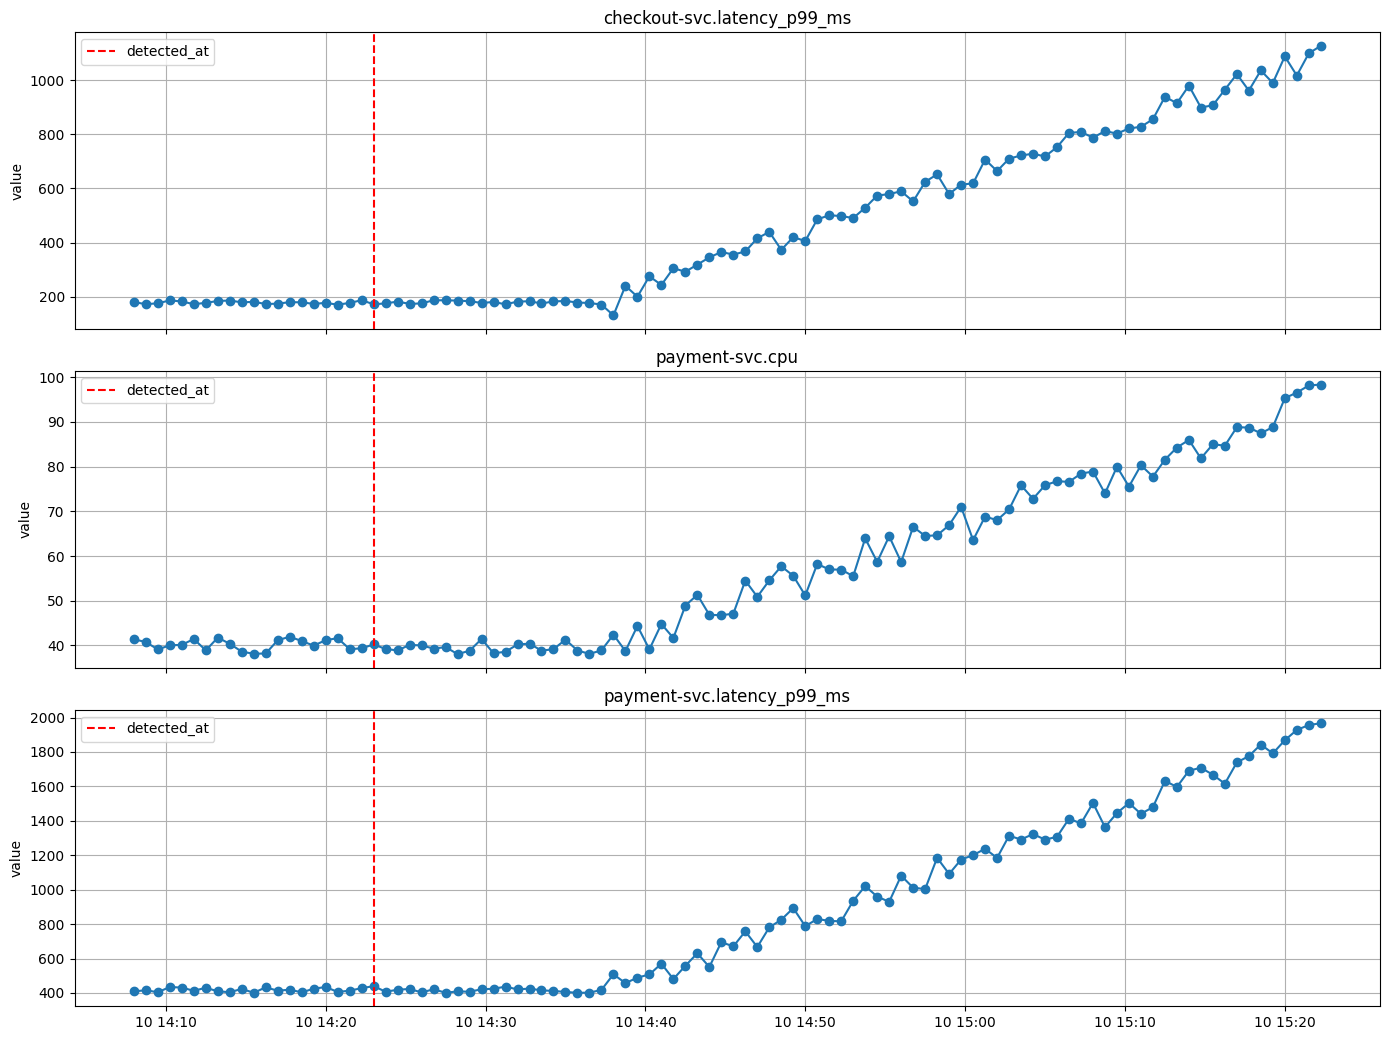

In [5]:
def plot_metrics(inc):
    df = metrics_to_df(inc)
    detected_at = pd.to_datetime(inc["detected_at"], utc=True)

    series_keys = df["series_key"].unique()
    fig, axes = plt.subplots(len(series_keys), 1, figsize=(14, 3.5 * len(series_keys)), sharex=True)

    if len(series_keys) == 1:
        axes = [axes]

    for ax, series_key in zip(axes, series_keys):
        s = df[df["series_key"] == series_key]
        ax.plot(s["ts"], s["value"], marker="o", linewidth=1.5)
        ax.axvline(detected_at, color="red", linestyle="--", label="detected_at")
        ax.set_title(series_key)
        ax.set_ylabel("value")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_metrics(incident)

## Visualize service dependency graph

### Đầy đủ từ `topology.json`

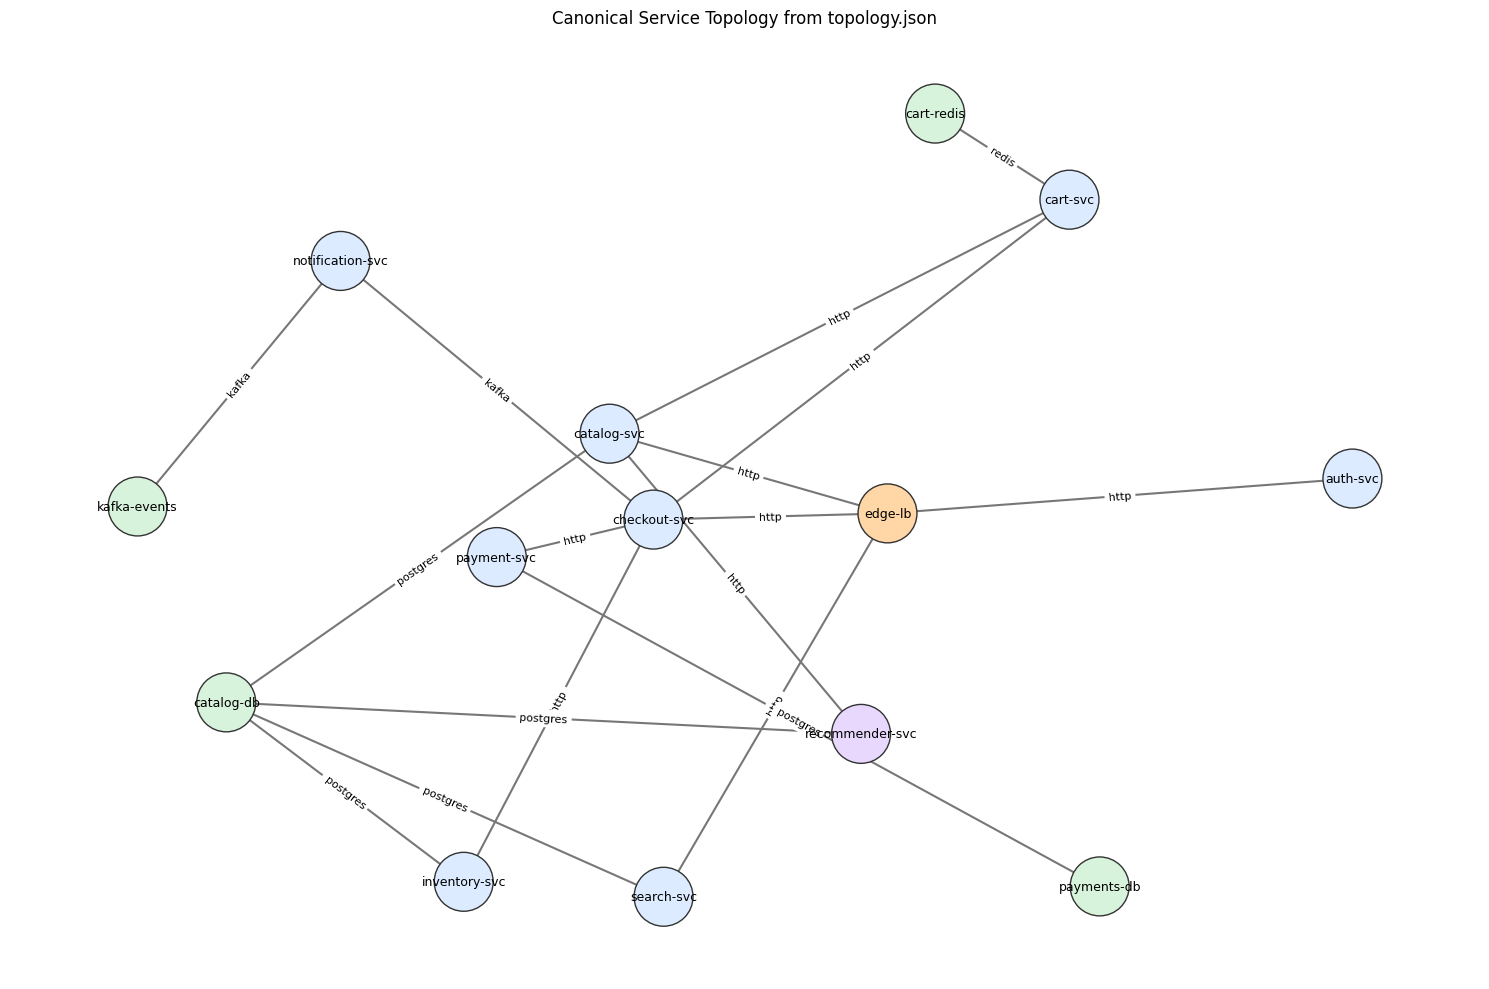

In [13]:
def load_topology():
    with open(DATA_DIR / "topology.json", "r", encoding="utf-8") as f:
        return json.load(f)

def plot_topology_graph(topology):
    G = nx.DiGraph()

    for node in topology["nodes"]:
        G.add_node(
            node["id"],
            tier=node.get("tier", "unknown")
        )

    for edge in topology["edges"]:
        G.add_edge(
            edge["from"],
            edge["to"],
            protocol=edge.get("protocol", "")
        )

    tier_colors = {
        "edge": "#FFD6A5",
        "api": "#DCEBFF",
        "store": "#D8F3DC",
        "ml": "#E9D8FD",
        "unknown": "#EEEEEE",
    }

    node_colors = [
        tier_colors.get(G.nodes[n].get("tier", "unknown"), "#EEEEEE")
        for n in G.nodes()
    ]

    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, seed=42, k=1.1)

    nx.draw_networkx_nodes(
        G, pos,
        node_size=1800,
        node_color=node_colors,
        edgecolors="#333333"
    )
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(
        G, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=15,
        width=1.5,
        edge_color="#777777"
    )

    edge_labels = nx.get_edge_attributes(G, "protocol")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Canonical Service Topology from topology.json")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

topology = load_topology()
plot_topology_graph(topology)

### Cách đọc Service Trace Graph
Trace graph: trong 'incident này' (tức là chỉ tính riêng trong file E..json) edge nào có lỗi/latency cao,Graph này được tạo trực tiếp từ `incident["traces"]`.

- Mỗi **node** là một service xuất hiện trong trace.
- Mỗi **edge** là một quan hệ gọi service, lấy từ cặp `from -> to`.
- Ví dụ edge `checkout-svc -> payment-svc` nghĩa là trong trace có request từ `checkout-svc` gọi sang `payment-svc`.

Màu và độ dày của edge thể hiện `error_rate`:

```text
error_rate = error_count / count

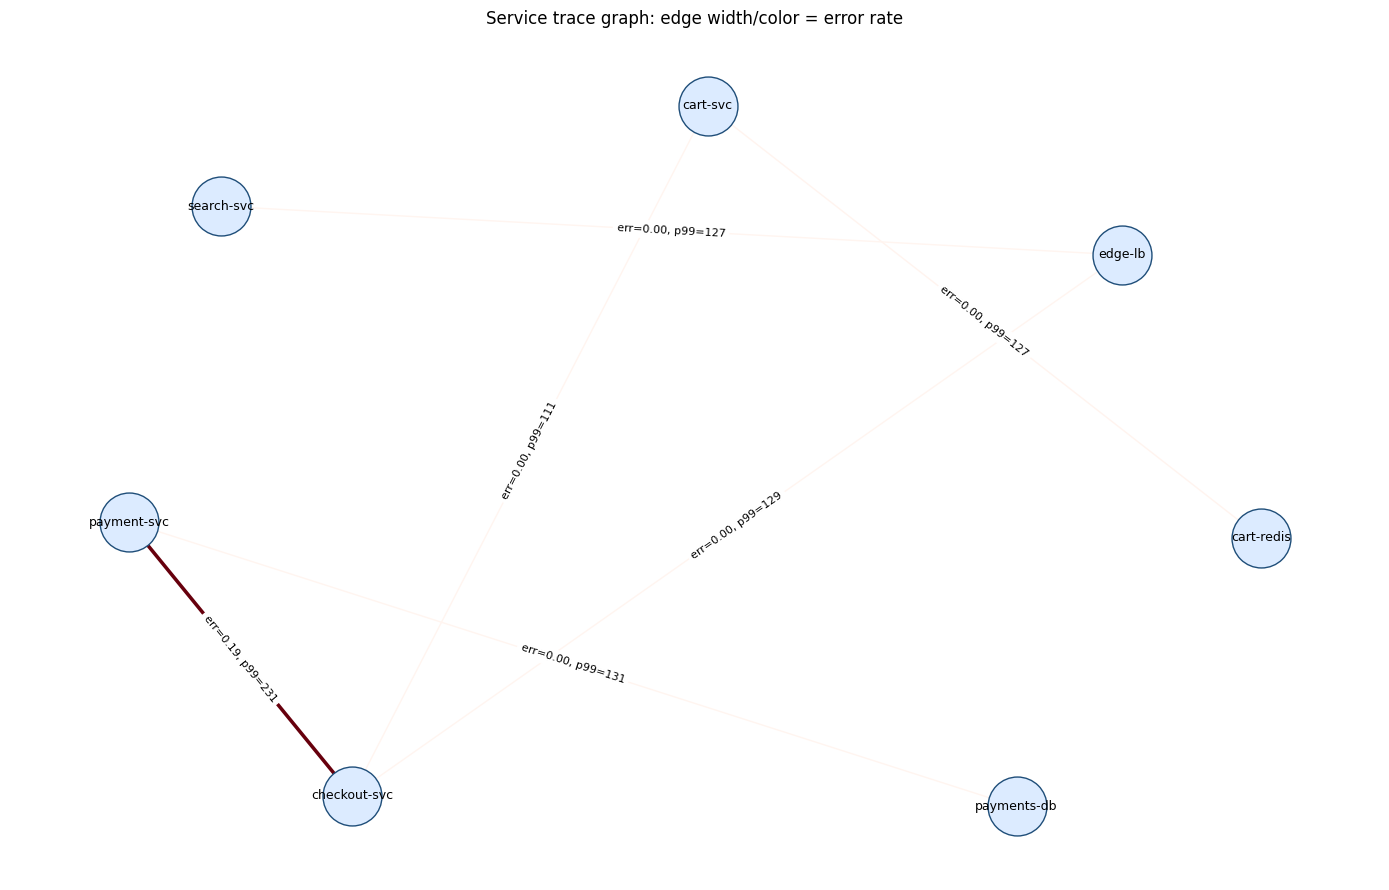

,from,to,total_count,total_errors,avg_p99,max_p99,avg_error_rate
2,checkout-svc,payment-svc,5356,1064,231.29250,570.5,0.193695
0,cart-svc,cart-redis,5173,24,127.43875,198.4,0.004125
1,checkout-svc,cart-svc,5094,20,110.50375,194.1,0.003266
4,edge-lb,search-svc,5085,16,126.84625,198.1,0.002829
3,edge-lb,checkout-svc,5029,16,129.14750,199.9,0.002817
5,payment-svc,payments-db,5162,16,131.48000,199.6,0.002684


In [15]:
def plot_trace_graph(inc):
    traces = pd.DataFrame(inc["traces"])

    traces["error_rate"] = traces["error_count"] / traces["count"].replace(0, np.nan)

    edge_summary = (
        traces
        .groupby(["from", "to"])
        .agg(
            total_count=("count", "sum"),
            total_errors=("error_count", "sum"),
            avg_p99=("p99_ms", "mean"),
            max_p99=("p99_ms", "max"),
            avg_error_rate=("error_rate", "mean"),
        )
        .reset_index()
    )

    G = nx.DiGraph()

    for _, row in edge_summary.iterrows():
        G.add_edge(
            row["from"],
            row["to"],
            weight=row["avg_error_rate"],
            label=f"err={row['avg_error_rate']:.2f}, p99={row['avg_p99']:.0f}"
        )

    plt.figure(figsize=(14, 9))
    pos = nx.spring_layout(G, seed=42, k=1.2)

    edge_rates = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [1 + 8 * rate for rate in edge_rates]

    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="#DCEBFF", edgecolors="#1F4E79")
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, arrows=True, width=edge_widths, edge_color=edge_rates, edge_cmap=plt.cm.Reds)

    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Service trace graph: edge width/color = error rate")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return edge_summary.sort_values(["avg_error_rate", "avg_p99"], ascending=False)

edge_summary = plot_trace_graph(incident)
display(edge_summary.head(20))

## Tính baseline stats đơn giản để kiểm tra plan
Quy ước tên feature:

- `baseline_*`: thống kê trước `detected_at`, đại diện cho trạng thái bình thường.
- `incident_*`: thống kê sau/đúng `detected_at`, đại diện cho trạng thái đang có sự cố.
- `change_*`: mức thay đổi giữa incident và baseline.

Ví dụ:
- `baseline_avg_value`: giá trị trung bình trước sự cố.
- `incident_peak_value`: giá trị cao nhất sau sự cố.
- `change_end_vs_start_ratio`: cuối window gấp bao nhiêu lần đầu window.
- `change_peak_vs_baseline_std`: peak sau sự cố lệch bao nhiêu lần so với dao động bình thường.

In [7]:
def metric_stats(inc):
    df = metrics_to_df(inc)
    rows = []

    for series_key, g in df.groupby("series_key"):
        baseline = g[g["phase"] == "baseline"]["value"]
        incident_part = g[g["phase"] == "incident"]["value"]

        if len(baseline) < 2 or len(incident_part) == 0:
            continue

        baseline_avg_value = baseline.mean()
        baseline_normal_variation = baseline.std(ddof=1)
        baseline_median_value = baseline.median()
        baseline_robust_variation = np.median(np.abs(baseline - baseline_median_value))

        window_start_value = g["value"].iloc[0]
        window_end_value = g["value"].iloc[-1]
        incident_peak_value = incident_part.max()

        change_peak_vs_baseline_std = (
            (incident_peak_value - baseline_avg_value) / baseline_normal_variation
            if baseline_normal_variation > 0 else np.nan
        )

        change_peak_vs_baseline_robust = (
            0.6745 * (incident_peak_value - baseline_median_value) / baseline_robust_variation
            if baseline_robust_variation > 0 else np.nan
        )

        change_end_vs_start_ratio = (
            window_end_value / window_start_value
            if window_start_value != 0 else np.nan
        )

        rows.append({
            "series_key": series_key,

            # Trước detected_at
            "baseline_sample_count": len(baseline),
            "baseline_avg_value": baseline_avg_value,
            "baseline_normal_variation": baseline_normal_variation,
            "baseline_median_value": baseline_median_value,
            "baseline_robust_variation": baseline_robust_variation,

            # Sau detected_at
            "incident_sample_count": len(incident_part),
            "incident_peak_value": incident_peak_value,
            "incident_end_value": window_end_value,

            # So sánh trước vs sau
            "change_peak_vs_baseline_std": change_peak_vs_baseline_std,
            "change_peak_vs_baseline_robust": change_peak_vs_baseline_robust,
            "change_end_vs_start_ratio": change_end_vs_start_ratio,
        })

    return pd.DataFrame(rows).sort_values(
        "change_peak_vs_baseline_robust", 
        ascending=False
    )

metric_stats(incident)

,series_key,baseline_sample_count,baseline_avg_value,baseline_normal_variation,baseline_median_value,baseline_robust_variation,incident_sample_count,incident_peak_value,incident_end_value,change_peak_vs_baseline_std,change_peak_vs_baseline_robust,change_end_vs_start_ratio
0,checkout-svc.latency_p99_ms,20,178.96650,4.997074,178.7760,4.0675,80,1126.483,1126.483,189.614256,157.155101,6.236998
2,payment-svc.latency_p99_ms,20,417.47645,11.536439,414.3745,10.0780,80,1966.727,1966.727,134.291920,103.895789,4.806214
1,payment-svc.cpu,20,40.21325,1.231213,40.2560,1.1080,80,98.376,98.376,47.240185,35.380812,2.376289


Trước detected_at, checkout latency p99 ổn định quanh 179ms. Sau detected_at, nó tăng dần lên 1126ms.
-> Tức là cuối window cao hơn đầu window khoảng 6.24 lần. z_peak rất lớn, nghĩa là mức tăng này vượt xa dao động bình thường.

## Convert logs + xem phân bố theo service/level

In [8]:
def logs_to_df(inc):
    df = pd.DataFrame(inc["logs"]).copy()
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    df["detected_at"] = pd.to_datetime(inc["detected_at"], utc=True)
    df["phase"] = np.where(df["ts"] < df["detected_at"], "baseline", "incident")
    return df.sort_values("ts")

logs_df = logs_to_df(incident)

display(logs_df.head())

pd.crosstab(logs_df["svc"], logs_df["level"]).sort_values(
    by=list(logs_df["level"].unique()), 
    ascending=False
)

,ts,svc,level,msg,detected_at,phase
0,2026-06-10 14:08:02+00:00,payment-svc,WARN,pool utilization=98% high,2026-06-10 14:23:00+00:00,baseline
1,2026-06-10 14:08:04+00:00,payment-svc,ERROR,Failed to forward request to t24-service: pool...,2026-06-10 14:23:00+00:00,baseline
2,2026-06-10 14:08:05+00:00,edge-lb,INFO,request accepted method=POST path=/api,2026-06-10 14:23:00+00:00,baseline
3,2026-06-10 14:08:05+00:00,checkout-svc,ERROR,upstream timeout target=payment-svc after_ms=9930,2026-06-10 14:23:00+00:00,baseline
4,2026-06-10 14:08:08+00:00,payment-svc,WARN,pool utilization=98% high,2026-06-10 14:23:00+00:00,baseline


level,ERROR,INFO,WARN
svc,,,
payment-svc,168,0,83
checkout-svc,83,83,0
edge-lb,0,83,0


## Log template parser đơn giản

In [9]:
def normalize_log_template(msg):
    s = msg

    s = re.sub(r"\b\d+(\.\d+)?ms\b", "<duration>", s)
    s = re.sub(r"\b\d+(\.\d+)?s\b", "<duration>", s)
    s = re.sub(r"\b\d+(\.\d+)?%\b", "<percent>", s)
    s = re.sub(r"\bv\d+(\.\d+)+\b", "<version>", s)
    s = re.sub(r"\b(order_id|product_id|attempt|revision|request_id|trace_id)=?[A-Za-z0-9_-]+\b", r"\1=<id>", s)
    s = re.sub(r"/[A-Za-z0-9_./-]+", "<path>", s)
    s = re.sub(r"\b\d+(\.\d+)?\b", "<num>", s)

    return s.strip()

def template_id(template):
    return "tpl_" + hashlib.md5(template.encode("utf-8")).hexdigest()[:8]

logs_df["template"] = logs_df["msg"].apply(normalize_log_template)
logs_df["template_id"] = logs_df["template"].apply(template_id)

logs_df[["ts", "svc", "level", "msg", "template", "template_id"]].head(10)

,ts,svc,level,msg,template,template_id
0,2026-06-10 14:08:02+00:00,payment-svc,WARN,pool utilization=98% high,pool utilization=<num>% high,tpl_2598816c
1,2026-06-10 14:08:04+00:00,payment-svc,ERROR,Failed to forward request to t24-service: pool...,Failed to forward request to t24-service: pool...,tpl_76ba23c7
2,2026-06-10 14:08:05+00:00,edge-lb,INFO,request accepted method=POST path=/api,request accepted method=POST path=<path>,tpl_c2886d7d
3,2026-06-10 14:08:05+00:00,checkout-svc,ERROR,upstream timeout target=payment-svc after_ms=9930,upstream timeout target=payment-svc after_ms=<...,tpl_c88925cb
4,2026-06-10 14:08:08+00:00,payment-svc,WARN,pool utilization=98% high,pool utilization=<num>% high,tpl_2598816c
5,2026-06-10 14:08:08+00:00,edge-lb,INFO,request accepted method=POST path=/api,request accepted method=POST path=<path>,tpl_c2886d7d
6,2026-06-10 14:08:13+00:00,checkout-svc,ERROR,upstream timeout target=payment-svc after_ms=1088,upstream timeout target=payment-svc after_ms=<...,tpl_c88925cb
7,2026-06-10 14:08:19+00:00,payment-svc,WARN,pool utilization=98% high,pool utilization=<num>% high,tpl_2598816c
8,2026-06-10 14:08:22+00:00,checkout-svc,INFO,checkout started order_id=4586,checkout started order_id=<id>,tpl_b7cc6770
9,2026-06-10 14:08:24+00:00,checkout-svc,ERROR,upstream timeout target=payment-svc after_ms=2798,upstream timeout target=payment-svc after_ms=<...,tpl_c88925cb


## Top log templates nghi vấn

In [10]:
template_summary = (
    logs_df
    .groupby(["svc", "level", "template_id", "template"])
    .agg(
        count=("msg", "size"),
        first_seen=("ts", "min"),
        last_seen=("ts", "max"),
        raw_example=("msg", "first"),
    )
    .reset_index()
    .sort_values(["count", "level"], ascending=[False, True])
)

template_summary.head(20)

,svc,level,template_id,template,count,first_seen,last_seen,raw_example
3,payment-svc,ERROR,tpl_1ebd5961,ConnectionPool: timeout acquiring connection (...,84,2026-06-10 14:08:27+00:00,2026-06-10 14:42:30+00:00,ConnectionPool: timeout acquiring connection (...
4,payment-svc,ERROR,tpl_76ba23c7,Failed to forward request to t24-service: pool...,84,2026-06-10 14:08:04+00:00,2026-06-10 14:42:48+00:00,Failed to forward request to t24-service: pool...
0,checkout-svc,ERROR,tpl_c88925cb,upstream timeout target=payment-svc after_ms=<...,83,2026-06-10 14:08:05+00:00,2026-06-10 14:41:44+00:00,upstream timeout target=payment-svc after_ms=9930
1,checkout-svc,INFO,tpl_b7cc6770,checkout started order_id=<id>,83,2026-06-10 14:08:22+00:00,2026-06-10 14:42:57+00:00,checkout started order_id=4586
2,edge-lb,INFO,tpl_c2886d7d,request accepted method=POST path=<path>,83,2026-06-10 14:08:05+00:00,2026-06-10 14:42:46+00:00,request accepted method=POST path=/api
5,payment-svc,WARN,tpl_2598816c,pool utilization=<num>% high,83,2026-06-10 14:08:02+00:00,2026-06-10 14:42:01+00:00,pool utilization=98% high


## Plot top templates

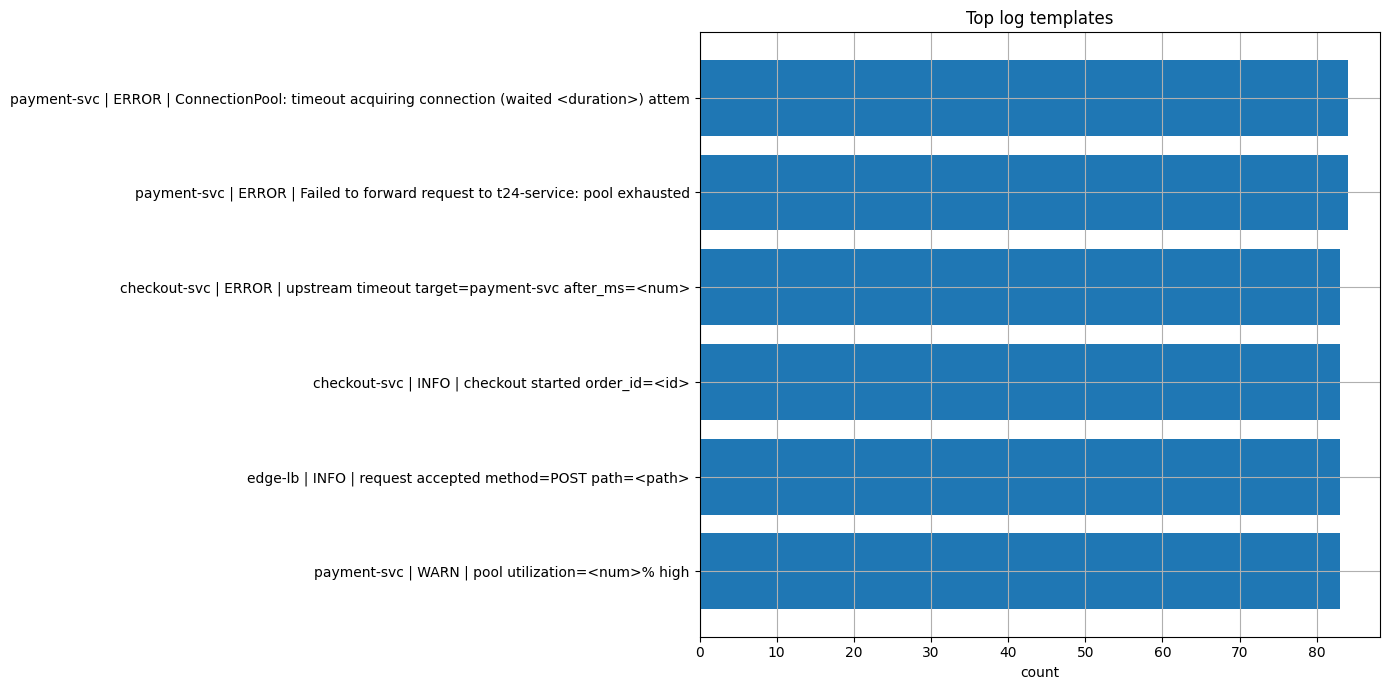

In [11]:
top = template_summary.head(15).copy()
top["label"] = top["svc"] + " | " + top["level"] + " | " + top["template"].str.slice(0, 70)

plt.figure(figsize=(14, 7))
plt.barh(top["label"][::-1], top["count"][::-1])
plt.xlabel("count")
plt.title("Top log templates")
plt.tight_layout()
plt.show()

## Chạy nhanh cho tất cả E01-E08
Cell này chạy nhanh toàn bộ E01-E08 để kiểm tra shape metrics và logs.

- Bảng metrics dùng quy ước:
  - `baseline_*`: thống kê trước `detected_at`
  - `incident_*`: thống kê sau/đúng `detected_at`
  - `change_*`: mức thay đổi giữa incident và baseline

- Bảng logs hiển thị top template xuất hiện nhiều nhất theo từng incident.
  - `template_count` cho biết template lặp lại bao nhiêu lần.
  - `raw_example` giữ một dòng log gốc để kiểm tra template có parse đúng không.

In [12]:
all_metric_stats = []
all_top_templates = []

# Mapping tên cột cũ -> tên cột dễ hiểu hơn để đọc bảng
metric_column_rename = {
    "baseline_n": "baseline_sample_count",
    "incident_n": "incident_sample_count",
    "baseline_mean": "baseline_avg_value",
    "baseline_std": "baseline_normal_variation",
    "baseline_median": "baseline_median_value",
    "baseline_mad": "baseline_robust_variation",
    "start": "window_start_value",
    "end": "window_end_value",
    "peak_after_detected": "incident_peak_value",
    "z_peak": "change_peak_vs_baseline_std",
    "robust_z_peak": "change_peak_vs_baseline_robust",
    "end_start_ratio": "change_end_vs_start_ratio",
}

for eid in [f"E{i:02d}" for i in range(1, 9)]:
    inc = load_incident(eid)

    # Metrics
    ms = metric_stats(inc).rename(columns=metric_column_rename)
    ms["eval_id"] = eid
    all_metric_stats.append(ms)

    # Logs
    ldf = logs_to_df(inc)
    ldf["template"] = ldf["msg"].apply(normalize_log_template)
    ldf["template_id"] = ldf["template"].apply(template_id)

    ts = (
        ldf.groupby(["svc", "level", "template_id", "template"])
        .agg(
            template_count=("msg", "size"),
            raw_example=("msg", "first"),
        )
        .reset_index()
        .sort_values("template_count", ascending=False)
        .head(10)
    )
    ts["eval_id"] = eid
    all_top_templates.append(ts)

all_metric_stats_df = pd.concat(all_metric_stats, ignore_index=True)
all_top_templates_df = pd.concat(all_top_templates, ignore_index=True)

# Sắp xếp metric theo case và mức bất thường robust
display(
    all_metric_stats_df.sort_values(
        ["eval_id", "change_peak_vs_baseline_robust"],
        ascending=[True, False]
    )
)

# Hiển thị top log templates
display(
    all_top_templates_df[
        ["eval_id", "svc", "level", "template_count", "template", "raw_example"]
    ]
)

,series_key,baseline_sample_count,baseline_avg_value,baseline_normal_variation,baseline_median_value,baseline_robust_variation,incident_sample_count,incident_peak_value,incident_end_value,change_peak_vs_baseline_std,change_peak_vs_baseline_robust,change_end_vs_start_ratio,eval_id
0,checkout-svc.latency_p99_ms,20,178.96650,4.997074e+00,178.7760,4.0675,80,1126.483,1126.483,1.896143e+02,157.155101,6.236998,E01
1,payment-svc.latency_p99_ms,20,417.47645,1.153644e+01,414.3745,10.0780,80,1966.727,1966.727,1.342919e+02,103.895789,4.806214,E01
2,payment-svc.cpu,20,40.21325,1.231213e+00,40.2560,1.1080,80,98.376,98.376,4.724018e+01,35.380812,2.376289,E01
3,edge-lb.error_rate,20,0.00100,2.224736e-19,0.0010,0.0000,80,0.957,0.948,4.297139e+18,NaN,948.000000,E02
4,edge-lb.tls_handshake_failures,20,0.00000,0.000000e+00,0.0000,0.0000,80,307.043,297.947,NaN,NaN,NaN,E02
5,esb.gc_pause_ms,20,50.50125,1.612233e+00,51.0675,1.0180,80,4228.845,4228.845,2.591649e+03,2768.085387,81.305180,E03
6,esb.mem_mb,20,269.63565,8.938534e+00,267.4775,8.0290,80,986.640,977.972,8.021498e+01,60.415383,3.491298,E03
7,esb.latency_p99_ms,20,895.04470,2.777426e+01,891.8130,25.4565,80,3038.680,2852.237,7.718066e+01,56.883774,3.019343,E03
8,datapower.dns_nxdomain_count,20,1.98230,4.985146e-02,1.9780,0.0275,80,151.196,151.196,2.993166e+03,3659.910582,79.367979,E04
9,datapower.latency_p99_ms,20,931.79550,2.725262e+01,933.1625,20.7210,80,4625.873,4625.873,1.355494e+02,120.203332,4.877349,E04


,eval_id,svc,level,template_count,template,raw_example
0,E01,payment-svc,ERROR,84,Failed to forward request to t24-service: pool...,Failed to forward request to t24-service: pool...
1,E01,payment-svc,ERROR,84,ConnectionPool: timeout acquiring connection (...,ConnectionPool: timeout acquiring connection (...
2,E01,checkout-svc,INFO,83,checkout started order_id=<id>,checkout started order_id=4586
3,E01,checkout-svc,ERROR,83,upstream timeout target=payment-svc after_ms=<...,upstream timeout target=payment-svc after_ms=9930
4,E01,edge-lb,INFO,83,request accepted method=POST path=<path>,request accepted method=POST path=/api
5,E01,payment-svc,WARN,83,pool utilization=<num>% high,pool utilization=98% high
6,E02,edge-lb,ERROR,125,TLS handshake failed: certificate has expired ...,TLS handshake failed: certificate has expired ...
7,E02,edge-lb,ERROR,125,x509: certificate signed by unknown authority ...,x509: certificate signed by unknown authority ...
8,E02,edge-lb,INFO,125,health check ok,health check ok
9,E02,edge-lb,WARN,125,tls_handshake_failures=<num> in last minute,tls_handshake_failures=1234 in last minute
